In [3]:
import pandas as pd

df = pd.read_csv('StPrex_Buildings_with_PV_Potential_and_HS.csv')

In [4]:
df['PV_Pot'].sum()

np.float64(16879036.230143763)

In [5]:
col = "BeginningOfOperation_Year"
df[col] = df[col].replace(-99, pd.NA)

df[[col]].head()

,BeginningOfOperation_Year
0,<NA>
1,<NA>
2,<NA>
3,<NA>
4,<NA>


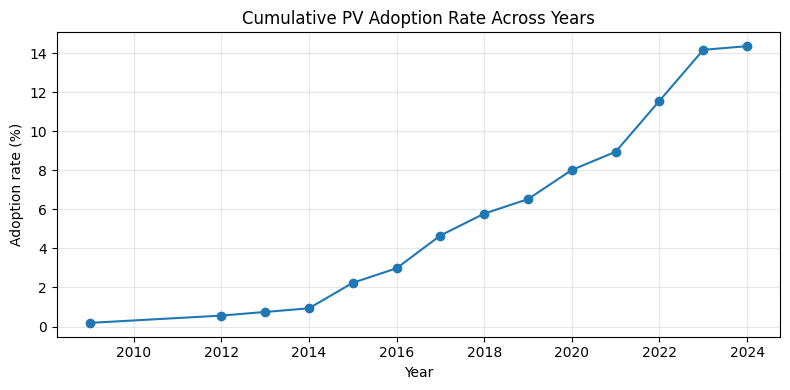

CSV created successfully with the following points:
    Year  Cumulative_Adoption_Rate
0   2009                  0.001866
1   2012                  0.005597
2   2013                  0.007463
3   2014                  0.009328
4   2015                  0.022388
5   2016                  0.029851
6   2017                  0.046642
7   2018                  0.057836
8   2019                  0.065299
9   2020                  0.080224
10  2021                  0.089552
11  2022                  0.115672
12  2023                  0.141791
13  2024                  0.143657


In [9]:
import matplotlib.pyplot as plt

# keep only rows with PV already installed and a known operation year
adopters = df.loc[df["has_pv_2024"] & df[col].notna(), col].astype(int)

# yearly new adopters, then cumulative adopters
adopters_per_year = adopters.value_counts().sort_index()
cumulative_adopters = adopters_per_year.cumsum()



# cumulative adoption rate over all buildings
total_buildings = len(df)
adoption_rate = cumulative_adopters / total_buildings

# plot cumulative adoption rate
ax = (adoption_rate * 100).plot(marker="o", figsize=(8, 4))
ax.set_title("Cumulative PV Adoption Rate Across Years")
ax.set_xlabel("Year")
ax.set_ylabel("Adoption rate (%)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

adoption_rate.rename("cumulative_adoption_rate").to_frame().head()

# Create a DataFrame from the Series
df_points = adoption_rate.reset_index()

# Rename columns for clarity
df_points.columns = ['Year', 'Cumulative_Adoption_Rate']

# Export to CSV
df_points.to_csv('pv_adoption_points.csv', index=False)

print("CSV created successfully with the following points:")
print(df_points)

In [7]:

stats = adopters_per_year.to_frame(name='New_Adopters')
stats['Cumulative_Adopters'] = cumulative_adopters
stats['Adoption_Rate_Pct'] = (adoption_rate * 100).round(2)


print("--- Historical Adoption Data ---")
print(stats)

val_2009 = stats.loc[2009, 'Adoption_Rate_Pct'] if 2009 in stats.index else 0.0
val_2024 = stats.loc[2024, 'Adoption_Rate_Pct'] if 2024 in stats.index else stats['Adoption_Rate_Pct'].max()

print(f"\nValue at t=0  (2009): {val_2009}%")
print(f"Value at t=360 (2024): {val_2024}%")

--- Historical Adoption Data ---
                           New_Adopters  Cumulative_Adopters  \
BeginningOfOperation_Year                                      
2009                                  1                    1   
2012                                  2                    3   
2013                                  1                    4   
2014                                  1                    5   
2015                                  7                   12   
2016                                  4                   16   
2017                                  9                   25   
2018                                  6                   31   
2019                                  4                   35   
2020                                  8                   43   
2021                                  5                   48   
2022                                 14                   62   
2023                                 14                   76   
2024   

In [8]:
# 1. Filter the original DataFrame for the year 2009
# Ensure you have replaced -99 with NA first as you did before
col = "BeginningOfOperation_Year"
df[col] = df[col].replace(-99, pd.NA)

# 2. Extract the specific rows
lines_2009 = df[df[col] == 2009]

# 3. Print the results
print("--- Historical Record for the year 2009 ---")
if len(lines_2009) > 0:
    print(lines_2009)
else:
    print("No records found for 2009.")

--- Historical Record for the year 2009 ---
               x             y  area_roof_solar_m2       PV_Pot  has_pv_2024  \
84  2.524463e+06  1.148251e+06          114.520325  14590.86484         True   

   BeginningOfOperation_Year                heating_system1 energy_source1  \
84                      2009  Chaudière (gén.) pour un bât.            Gaz   

    update_date  
84         2001  
